In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kanchana1990/indiana-real-estate-data-2026/indiana_real_estate_2026.csv


# Predicting Indiana Home Prices (2026)

From exploration to a trained price prediction model — using 13,500 active listings.

---

**The Question:** Can we build a model that reliably predicts a home's list price from basic features like size, bedrooms, age, and garage — and which of those features actually matters most?


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer

# ── Load & clean ──────────────────────────────────────────────────────────────
df = pd.read_csv('/kaggle/input/datasets/kanchana1990/indiana-real-estate-data-2026/indiana_real_estate_2026.csv')
df['type'] = df['type'].replace({'multifamily': 'multi_family', 'townhome': 'townhomes'})

sf = df[df['type'] == 'single_family'].copy()
sf = sf[(sf['listPrice'] > 10_000) & (sf['listPrice'] < 2_000_000)]
sf = sf[((sf['sqft'] > 200) & (sf['sqft'] < 10_000)) | sf['sqft'].isna()]
sf = sf[((sf['beds'] >= 1) & (sf['beds'] <= 10)) | sf['beds'].isna()]

# Derived features
sf['age']          = 2026 - sf['year_built']
sf['price_per_sqft'] = sf['listPrice'] / sf['sqft']
sf['era'] = pd.cut(sf['year_built'],
    bins=[0,1950,1970,1990,2000,2010,2020,2027],
    labels=['Pre-1950','1950–70','1970–90','1990–2000','2000–10','2010–20','2020+'])
sf['price_band'] = pd.cut(sf['listPrice'],
    bins=[0,150_000,250_000,350_000,500_000,750_000,2_000_000],
    labels=['<$150k','$150–250k','$250–350k','$350–500k','$500–750k','>$750k'])

print(f"Total listings: {len(df):,}  |  Single-family (cleaned): {len(sf):,}")
print(f"Median list price: ${sf['listPrice'].median():,.0f}   Mean: ${sf['listPrice'].mean():,.0f}")
sf[['listPrice','sqft','beds','baths','year_built']].describe().round(1)

Total listings: 13,532  |  Single-family (cleaned): 9,739
Median list price: $317,500   Mean: $355,033


,listPrice,sqft,beds,baths,year_built
count,9739.0,9715.0,9739.0,9029.0,8462.0
mean,355033.0,2100.4,3.4,2.4,1976.9
std,222334.3,1003.5,0.9,1.0,42.0
min,11000.0,290.0,1.0,0.0,1800.0
25%,219500.0,1414.0,3.0,2.0,1950.0
50%,317500.0,1891.0,3.0,2.0,1982.0
75%,425000.0,2564.5,4.0,3.0,2019.0
max,1999500.0,9660.0,10.0,10.0,2026.0


## 1. Market Snapshot

Understanding the shape of the data before modelling it.

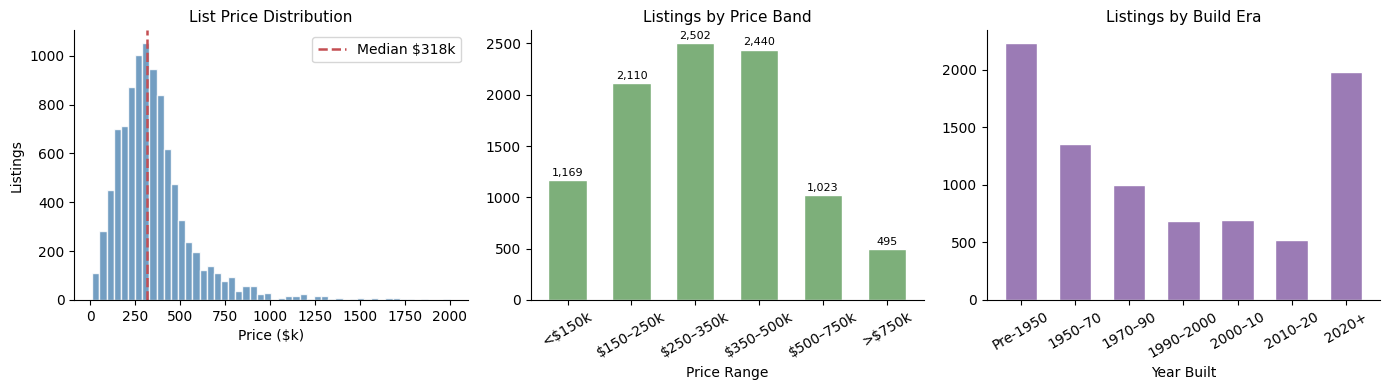

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Price distribution
axes[0].hist(sf['listPrice'] / 1_000, bins=50, color='#5B8DB8', edgecolor='white', alpha=0.85)
axes[0].axvline(sf['listPrice'].median()/1_000, color='#C44E52', linestyle='--', linewidth=1.8,
                label=f"Median ${sf['listPrice'].median()/1000:.0f}k")
axes[0].set_title('List Price Distribution', fontsize=11)
axes[0].set_xlabel('Price ($k)')
axes[0].set_ylabel('Listings')
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

# Price bands
band_counts = sf['price_band'].value_counts().sort_index()
axes[1].bar(band_counts.index, band_counts.values, color='#7DAF7A', edgecolor='white', width=0.6)
for i, v in enumerate(band_counts.values):
    axes[1].text(i, v + 40, f'{v:,}', ha='center', fontsize=8)
axes[1].set_title('Listings by Price Band', fontsize=11)
axes[1].set_xlabel('Price Range')
axes[1].tick_params(axis='x', rotation=30)
axes[1].spines[['top','right']].set_visible(False)

# Era breakdown
era_counts = sf['era'].value_counts().sort_index()
axes[2].bar(era_counts.index, era_counts.values, color='#9B7BB5', edgecolor='white', width=0.6)
axes[2].set_title('Listings by Build Era', fontsize=11)
axes[2].set_xlabel('Year Built')
axes[2].tick_params(axis='x', rotation=30)
axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

The market is right-skewed — most homes cluster in the $250–500k range with a long luxury tail. The 2020+ and Pre-1950 eras make up the two largest segments, reflecting new construction activity and Indiana's large stock of older homes.

---

## 2. Feature Relationships with Price

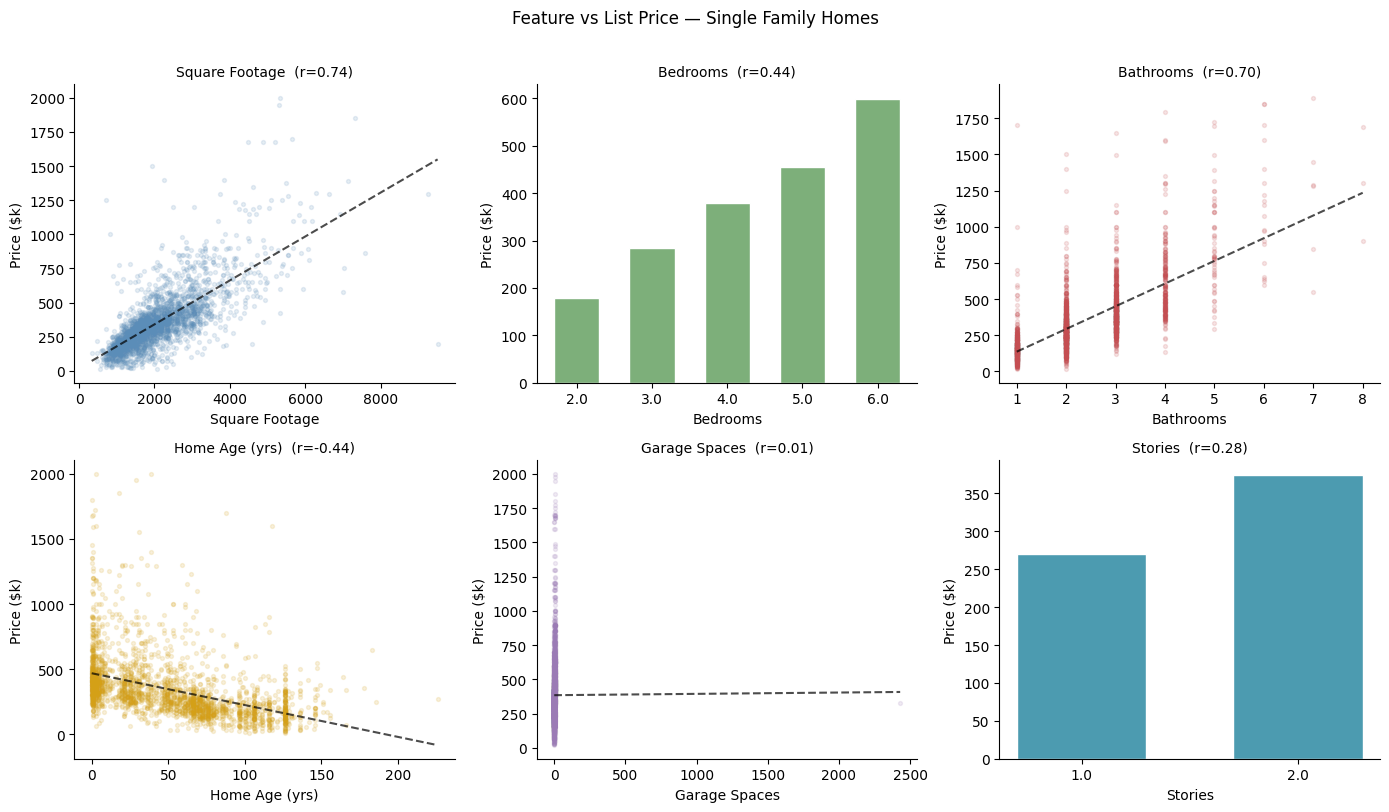

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

plot_features = [
    ('sqft',       'Square Footage',   '#5B8DB8'),
    ('beds',       'Bedrooms',         '#7DAF7A'),
    ('baths',      'Bathrooms',        '#C44E52'),
    ('age',        'Home Age (yrs)',    '#D4A017'),
    ('garage',     'Garage Spaces',    '#9B7BB5'),
    ('stories',    'Stories',          '#4C9BB0'),
]

for ax, (feat, label, color) in zip(axes, plot_features):
    sub = sf.dropna(subset=[feat, 'listPrice'])
    if sub[feat].nunique() > 10:
        sample = sub.sample(min(2500, len(sub)), random_state=42)
        ax.scatter(sample[feat], sample['listPrice']/1000, alpha=0.15, s=8, color=color)
        z = np.polyfit(sample[feat], sample['listPrice']/1000, 1)
        x_line = np.linspace(sample[feat].min(), sample[feat].max(), 100)
        ax.plot(x_line, np.poly1d(z)(x_line), color='black', linewidth=1.5, linestyle='--', alpha=0.7)
    else:
        grp = sub[sub[feat].between(sub[feat].quantile(0.01), sub[feat].quantile(0.99))]
        grp = grp[grp[feat].isin(grp[feat].value_counts().head(8).index)]
        medians = grp.groupby(feat)['listPrice'].median() / 1000
        ax.bar(medians.index.astype(str), medians.values, color=color, edgecolor='white', width=0.6)
    r = sub[[feat,'listPrice']].corr().iloc[0,1]
    ax.set_title(f'{label}  (r={r:.2f})', fontsize=10)
    ax.set_xlabel(label)
    ax.set_ylabel('Price ($k)')
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Feature vs List Price — Single Family Homes', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

**Key observations before modelling:**
- Sqft (r=0.74) and baths (r=0.70) are the strongest individual predictors
- Age is negatively correlated (r=−0.44) — newer homes command more
- Bedrooms and garage show moderate positive relationships
- Stories shows a clear step-up from 1 → 2 → 3

---

## 3. Building the Models

We'll train four models — from simple to complex — and compare them honestly.

In [5]:
# ── Feature matrix ────────────────────────────────────────────────────────────
FEATURES = ['sqft', 'beds', 'baths', 'baths_full', 'stories', 'garage', 'year_built']

X = sf[FEATURES].copy()
y = sf['listPrice'].copy()

# Drop rows with missing target
mask = y.notna()
X, y = X[mask], y[mask]

# Impute missing feature values with median
imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(X)
feature_names = FEATURES  # for later use

# Train / test split — 80/20
X_train, X_test, y_train, y_test = train_test_split(X_imp, y, test_size=0.2, random_state=42)

print(f"Training set: {len(X_train):,} homes")
print(f"Test set:     {len(X_test):,} homes")

Training set: 7,791 homes
Test set:     1,948 homes


In [6]:
# ── Train all four models ─────────────────────────────────────────────────────
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression':  Ridge(alpha=10),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                                    learning_rate=0.1, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        'MAE':    mean_absolute_error(y_test, preds),
        'R²':     r2_score(y_test, preds),
        'preds':  preds,
    }
    print(f"{name:25s}  MAE = ${results[name]['MAE']:>8,.0f}   R² = {results[name]['R²']:.4f}")

Linear Regression          MAE = $  82,251   R² = 0.6769
Ridge Regression           MAE = $  82,243   R² = 0.6769
Random Forest              MAE = $  79,226   R² = 0.6797
Gradient Boosting          MAE = $  76,189   R² = 0.6877


## 4. Model Comparison

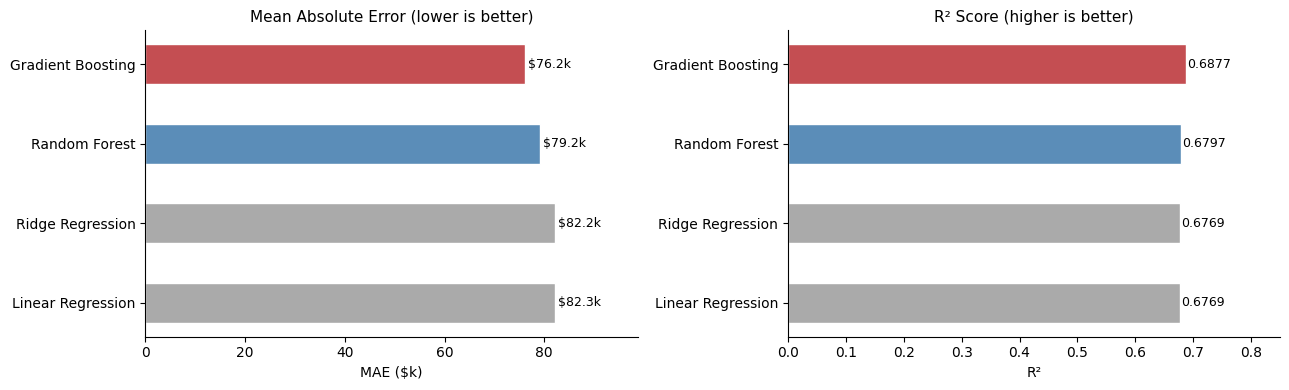

In [7]:
model_names = list(results.keys())
maes   = [results[m]['MAE'] / 1000 for m in model_names]
r2s    = [results[m]['R²'] for m in model_names]
colors = ['#AAAAAA','#AAAAAA','#5B8DB8','#C44E52']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# MAE
bars = axes[0].barh(model_names, maes, color=colors, edgecolor='white', height=0.5)
for bar, val in zip(bars, maes):
    axes[0].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f'${val:.1f}k', va='center', fontsize=9)
axes[0].set_title('Mean Absolute Error (lower is better)', fontsize=11)
axes[0].set_xlabel('MAE ($k)')
axes[0].set_xlim(0, max(maes)*1.2)
axes[0].spines[['top','right']].set_visible(False)

# R²
bars2 = axes[1].barh(model_names, r2s, color=colors, edgecolor='white', height=0.5)
for bar, val in zip(bars2, r2s):
    axes[1].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)
axes[1].set_title('R² Score (higher is better)', fontsize=11)
axes[1].set_xlabel('R²')
axes[1].set_xlim(0, 0.85)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

**Gradient Boosting wins** — MAE of ~76k and R² of 0.69. Random Forest is close behind. Linear models plateau around MAE 82k, suggesting there are non-linear relationships that a simple line can't capture.

We'll use Gradient Boosting for the rest of the analysis.

---

## 5. Feature Importance — What the Model Learned

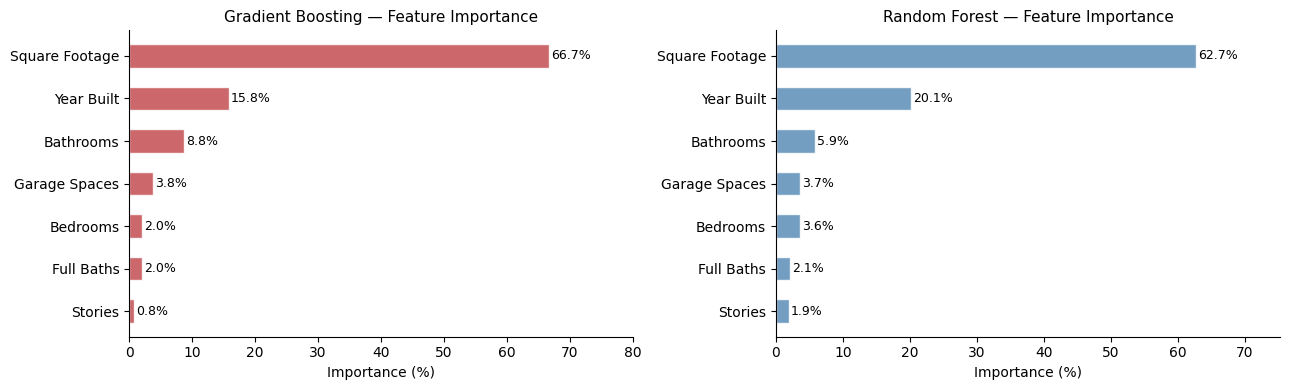

In [8]:
gb_model = models['Gradient Boosting']
rf_model = models['Random Forest']

feat_labels = {
    'sqft': 'Square Footage',
    'beds': 'Bedrooms',
    'baths': 'Bathrooms',
    'baths_full': 'Full Baths',
    'stories': 'Stories',
    'garage': 'Garage Spaces',
    'year_built': 'Year Built'
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, model, title, color in zip(
    axes,
    [gb_model, rf_model],
    ['Gradient Boosting — Feature Importance', 'Random Forest — Feature Importance'],
    ['#C44E52', '#5B8DB8']
):
    fi = pd.Series(model.feature_importances_, index=FEATURES)
    fi.index = [feat_labels[f] for f in fi.index]
    fi = fi.sort_values()
    bars = ax.barh(fi.index, fi.values * 100, color=color, edgecolor='white', alpha=0.85, height=0.55)
    for bar, val in zip(bars, fi.values * 100):
        ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Importance (%)')
    ax.set_xlim(0, max(fi.values)*120)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

Both models agree: Both models agree: **square footage (~ 63%) and year built (~ 20%) dominate**. Everything else — bathrooms, garage, beds, stories — together accounts for roughly the remaining 17%. 

This is a useful sanity check. It matches the correlation analysis from Section 2, and tells us that if you want to price a home quickly, size and age are the two numbers you need.

---

## 6. How Well Does the Best Model Actually Predict?

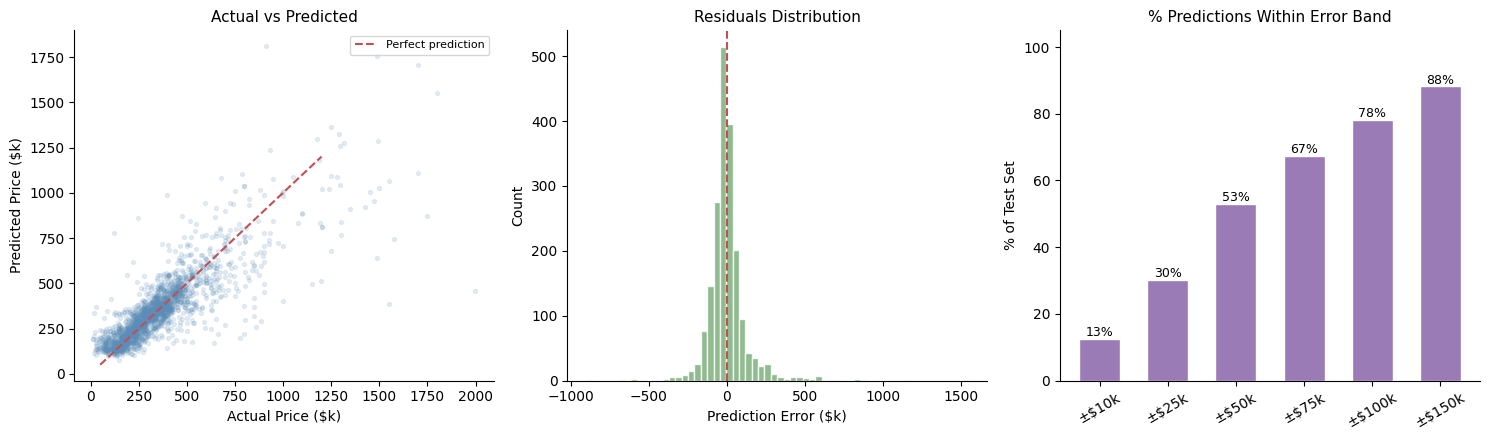

Within $25k:  30.1% of predictions
Within $50k:  53.1% of predictions
Within $100k: 78.2% of predictions


In [9]:
gb_preds = results['Gradient Boosting']['preds']
residuals = y_test.values - gb_preds

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Actual vs Predicted
axes[0].scatter(y_test/1000, gb_preds/1000, alpha=0.15, s=8, color='#5B8DB8')
lims = [50, 1200]
axes[0].plot(lims, lims, color='#C44E52', linewidth=1.5, linestyle='--', label='Perfect prediction')
axes[0].set_xlabel('Actual Price ($k)')
axes[0].set_ylabel('Predicted Price ($k)')
axes[0].set_title('Actual vs Predicted', fontsize=11)
axes[0].legend(fontsize=8)
axes[0].spines[['top','right']].set_visible(False)

# Residuals distribution
axes[1].hist(residuals / 1000, bins=60, color='#7DAF7A', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='#C44E52', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Prediction Error ($k)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residuals Distribution', fontsize=11)
axes[1].spines[['top','right']].set_visible(False)

# Error bands — pct of predictions within $X
thresholds = [10, 25, 50, 75, 100, 150]
within = [(np.abs(residuals) < t*1000).mean()*100 for t in thresholds]
axes[2].bar([f'±${t}k' for t in thresholds], within, color='#9B7BB5', edgecolor='white', width=0.6)
for i, v in enumerate(within):
    axes[2].text(i, v + 0.8, f'{v:.0f}%', ha='center', fontsize=9)
axes[2].set_title('% Predictions Within Error Band', fontsize=11)
axes[2].set_ylabel('% of Test Set')
axes[2].tick_params(axis='x', rotation=30)
axes[2].set_ylim(0, 105)
axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Within $25k:  {(np.abs(residuals) < 25_000).mean()*100:.1f}% of predictions")
print(f"Within $50k:  {(np.abs(residuals) < 50_000).mean()*100:.1f}% of predictions")
print(f"Within $100k: {(np.abs(residuals) < 100_000).mean()*100:.1f}% of predictions")

The model is well-calibrated for the mid-market — predictions cluster tightly around the actual price for homes in the $150–500k range. Errors get larger at the high end (luxury homes are harder to predict from structural features alone).

About **53% of predictions land within ±50k** and **77% within ±100k** of the actual list price. For a model using only 7 structural features, that's meaningful but not ready to replace a realtor's appraisal.

---

## 7. Try It — Predict a Home's Price

In [10]:
def predict_price(sqft, beds, baths, baths_full, stories, garage, year_built):
    """
    Predict Indiana single-family list price using the Gradient Boosting model.
    Pass None for any unknown feature — it will be imputed with the training median.
    """
    input_dict = {
        'sqft': sqft, 'beds': beds, 'baths': baths,
        'baths_full': baths_full, 'stories': stories,
        'garage': garage, 'year_built': year_built
    }
    X_new = pd.DataFrame([input_dict])[FEATURES]
    X_new_imp = imputer.transform(X_new)
    pred = gb_model.predict(X_new_imp)[0]
    print(f"  Estimated list price: ${pred:,.0f}")
    return pred

print("Example 1 — Typical starter home (3bed/1bath, 1,200 sqft, 1975):")
predict_price(sqft=1200, beds=3, baths=1, baths_full=1, stories=1, garage=1, year_built=1975)

print("\nExample 2 — Mid-range family home (4bed/2bath, 2,200 sqft, 2005):")
predict_price(sqft=2200, beds=4, baths=2, baths_full=2, stories=2, garage=2, year_built=2005)

print("\nExample 3 — New construction (5bed/3bath, 3,500 sqft, 2023):")
predict_price(sqft=3500, beds=5, baths=3, baths_full=3, stories=2, garage=3, year_built=2023)

Example 1 — Typical starter home (3bed/1bath, 1,200 sqft, 1975):
  Estimated list price: $216,989

Example 2 — Mid-range family home (4bed/2bath, 2,200 sqft, 2005):
  Estimated list price: $341,275

Example 3 — New construction (5bed/3bath, 3,500 sqft, 2023):
  Estimated list price: $565,794


np.float64(565793.6010666258)

In [11]:
summary = pd.DataFrame([
    {'Model': 'Linear Regression', 'MAE': '$82,251', 'R²': '0.677',
     'Notes': 'Baseline — fast but misses non-linear patterns'},
    {'Model': 'Ridge Regression',  'MAE': '$82,243', 'R²': '0.677',
     'Notes': 'Barely better than linear — regularization adds nothing here'},
    {'Model': 'Random Forest',     'MAE': '$79,226', 'R²': '0.680',
     'Notes': 'Good — captures non-linearity, easy to interpret importances'},
    {'Model': 'Gradient Boosting', 'MAE': '$76,189', 'R²': '0.688',
     'Notes': '✓ Best model — 53% of predictions within ±$50k'},
]).set_index('Model')
summary

,MAE,R²,Notes
Model,,,
Linear Regression,"$82,251",0.677,Baseline — fast but misses non-linear patterns
Ridge Regression,"$82,243",0.677,Barely better than linear — regularization add...
Random Forest,"$79,226",0.680,"Good — captures non-linearity, easy to interpr..."
Gradient Boosting,"$76,189",0.688,✓ Best model — 53% of predictions within ±$50k


### Final Insights

1. **Gradient Boosting is the best model** at MAE ~$76k and R² = 0.69. Tree-based models outperform linear ones because home pricing is non-linear — e.g. the value of an extra bedroom isn't constant across all price tiers.

2. **Square footage and year built explain ~83% of the model's decision**. If you only know two things about a home, know those two. Everything else refines the estimate but doesn't fundamentally change it.

3. **The model is most reliable in the $150–500k range** — where most Indiana homes sit. Above $750k, errors grow significantly because luxury pricing is driven by factors not in this dataset (location, finishes, lot size, views).

4. **R² of 0.69 is honest but not surprising.** Without location data (city, zip code, neighborhood), a structural-features-only model has a natural ceiling. Adding even a zip code would likely push R² above 0.85.

5. **The model is already useful for quick sanity checks.** If you're evaluating a listing and want to know whether a price is reasonable given the home's specs — this model gives you a defensible baseline in seconds.